# **Mount Drive**

# **Wheather Index - Crop Failure Visual Inspection: Irigation & Temperature Treciles**

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [20]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)
dft

dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])
# dfd.iloc[0:5,:]

dft = dft.rename(columns={'Year':'year'}).drop(columns=['State','County'])
# fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
# df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
# dft = pd.merge(dft,df_fips_obj,on=['OBJECTID'])
# dft.iloc[0:5,:]

In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi.columns

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail.iloc[0:10,:]

In [ ]:
dft

In [ ]:
temps_ths = [
    'Thr26', 'Thr27', 'Thr28', 'Thr29',
    'Thr30', 'Thr31', 'Thr32', 'Thr33',
    'Thr34', 'Thr35', 'Thr36']

# drought_ths = ['PDSI', 'SPEI3', 'SPEI6', 'SPEI9', 'SPEI12', 'SPI3','SPI6', 'SPI9', 'SPI12']

temps_cls = [-1,0,1]

join_cols = ['FIPS', 'year']
df_fail = pd.merge(df_fail,dft,on=join_cols)
df_fail

In [ ]:
crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']

irig = ['I' , 'N' , 'ALL']
irig_conf = {
    irig[0]: ['Irrigation','#0000ff'],
    irig[1]: ['Non-Irrigation', '#ff9900'],
    irig[2]: ['All Irrigation Types','#00ff00']
}

#
# themes = ['RPL_THEME1','RPL_THEME2','RPL_THEME3','RPL_THEME4']
themes = ['RPL_THEME1','RPL_THEME2','RPL_THEME3','RPL_THEME4']

theme_colors = {
    themes[0]: '#2c7bb6',    themes[1]: '#abd9e9',
    themes[2]: '#fdae61',    themes[3]: '#d7191c'
}

fail_share_th = 0.3

# df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']

for crop in crops:
  for theme in themes:
    bins = [0, 0.25, 0.5, 0.75, 1]
    labels = [1, 2, 3, 4]
    df_svi['cat_theme'] = pd.cut(df_svi[theme], bins=bins, labels=labels)

    for th in temps_ths:
      fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharey=True)
      i = 0

      for ig in irig:
        cond0 = (df_fail['fail_share'] > 0)
        cond1 = (df_fail['fail_share'] < fail_share_th)
        cond2 = (df_fail['Crop'] == crop)
        cond3 = (df_fail['Irrigation Practice'] == ig)
        df_fail_gt0 = df_fail[(cond0) & (cond1) & (cond2) & (cond3)]
        # df_fail_gt0 = df_fail[(cond0) & (cond2) & (cond3)]

        join_cols = ['FIPS', 'year']
        df_merge = pd.merge(df_fail_gt0,df_svi,on=join_cols)

        for tcls in temps_cls:
          cond_th = df_merge[th] == tcls
          df_merge_th = df_merge[cond_th]

          # ax = axes[i//3,i%3]
          # i = i + 1
          # sns.violinplot(x='cat_theme', y='fail_share', data=df_merge_th,
          #               ax=ax, cut=0,
          #               palette=[irig_conf.get(ig)[1]],
          #               #  facecolor='lightblue', size=5
          #               )
          # print(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}:{tcls}')
          # ax.set_title(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}:{tcls}',fontdict={'fontsize':9})
          # ax.set_xlabel('')
          # ax.set_xticklabels([])
          # ylim = (df_fail_gt0.fail_share.min(), df_fail_gt0.fail_share.max())
          # ax.set_ylim(ylim)

          ax = axes[i//3,i%3]

          sns.boxplot(x='cat_theme', y='fail_share', data=df_merge_th, ax=ax, whis=[1,99])
          sns.swarmplot(x="cat_theme", y="fail_share", data=df_merge_th, size=3 ,color="0.15", ax=ax)

          # ax.set_title(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}:{tcls}',fontdict={'fontsize':9})
          # ax.set_xlabel('')
          # ax.set_xticklabels([])

          ylim = (df_fail_gt0.fail_share.min(), df_fail_gt0.fail_share.max())
          ax.set_ylim(ylim)

          ax.set_xticks([])
          # ax.set_yticks([])

          if i < 3:
            ax.set_title(f'{th}:{tcls}', fontdict={'fontsize':8})
          ax.set_ylabel('')
          if i % 3 == 0:
            ax.set_ylabel(f'{irig_conf.get(ig)[0]}', fontdict={'fontsize':6})
          ax.set_xlabel('')
          ax.set_xticklabels([])
          i = i + 1

      plt.suptitle(f'{crop} {theme} Temperature:{th}',fontsize=10)
      # out_path = '<DATA_ROOT>/ProcessedData/20231104-CropTemperatureThr-violinplot-fth01/'
      out_path = '<DATA_ROOT>/ProcessedData/20231111-CropTemp-boxplots_swarm/'
      plt.savefig(out_path + crop + '_' + theme + '_' + th + '.jpg' , dpi=400)

  #   plt.tight_layout()
  #   plt.show()
  #   break
  # break
  #




Output hidden; open in https://colab.research.google.com to view.

In [2]:
df_merge

NameError: ignored

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a sample DataFrame
df = df_fail

# Create a histogram of the 'Age' column
plt.hist(df['fail_share'], bins=10, color='blue', edgecolor='black')
plt.xlabel('fail_share')
plt.ylabel('Frequency')
plt.title('fail_share Distribution')
plt.show()


# **Wheather Index - Crop Failure Visual Inspection: Temperature Thresholds & Temperature Treciles**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
import pandas as pd
fpath1 = '<DATA_ROOT>/WeatherIndex/Tercile_temperature.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Tercile_drought.csv'
dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)

In [ ]:
dft = dft.rename(columns={'Year':'year'})

In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi.columns

Index(['State', 'County', 'EPL_POV', 'EPL_UNEMP', 'EPL_PCI', 'EPL_NOHSDP',
       'RPL_THEME1', 'EPL_AGE65', 'EPL_AGE17', 'EPL_DISABL', 'EPL_SNGPNT',
       'RPL_THEME2', 'EPL_MINRTY', 'EPL_LIMENG', 'RPL_THEME3', 'EPL_MUNIT',
       'EPL_MOBILE', 'EPL_CROWD', 'EPL_NOVEH', 'EPL_GROUPQ', 'RPL_THEME4',
       'RPL_THEMES', 'year', 'EPL_HBURD', 'EPL_UNINSU'],
      dtype='object')

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_agg_irig.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['State', 'County'])
cond = df_fail['year']>2011
df_fail = df_fail[cond]
df_fail

In [ ]:
cond = df_fail['Failed Acres']>0
df_fail[cond].groupby(['Irrigation Practice','Crop']).count()

In [ ]:
tenth_percentile = df_fail['Planted Acres'].quantile(0.10)
ninetieth_percentile = df_fail['Planted Acres'].quantile(0.90)

# Use boolean indexing to filter records
df_fail = df_fail[(df_fail['Planted Acres'] >= tenth_percentile) & (df_fail['Planted Acres'] <= ninetieth_percentile)]
df_fail

In [ ]:
# temps_ths = [
#      'Thr26', 'Thr27', 'Thr28',
#     'Thr29', 'Thr30', 'Thr31', 'Thr32',
#      'Thr33', 'Thr34', 'Thr35', 'Thr36'
#     ]

temps_ths = ['Thr27', 'Thr28', 'Thr29', 'Thr30', 'Thr31', 'Thr32', 'Thr33']

# drought_ths = ['PDSI1', 'PDSI2', 'SPEI3_1', 'SPEI3_2',
#        'SPEI6_1', 'SPEI6_2', 'SPEI9_1', 'SPEI9_2', 'SPEI12_1', 'SPIE12_2',
#        'SPI3_1', 'SPI3_2', 'SPI6_1', 'SPI6_2', 'SPI9_1', 'SPI9_2', 'SPI12_1',
#        'SPI12_2'
#     ]

temps_cls = [-1,0,1]

join_cols = ['State', 'County', 'year']
df_fail = pd.merge(df_fail,dft,on=join_cols,how='inner')
df_fail

In [ ]:
# crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
crops = ['SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']

irig = ['I' , 'N' , 'ALL']
irig_conf = {
    irig[0]: ['Irrigation','#0000ff'],
    irig[1]: ['Non-Irrigation', '#ff9900'],
    irig[2]: ['All Irrigation Types','#00ff00']
}

#
themes = ['RPL_THEME1','RPL_THEME2','RPL_THEME3','RPL_THEME4']

theme_colors = {
    themes[0]: '#2c7bb6',    themes[1]: '#abd9e9',
    themes[2]: '#fdae61',    themes[3]: '#d7191c'
}

fail_share_th = 0.15

df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']

for crop in crops:
  for theme in themes:
    bins = [0, 0.25, 0.5, 0.75, 1]
    labels = [1, 2, 3, 4]
    df_svi['cat_theme'] = pd.cut(df_svi[theme], bins=bins, labels=labels)

    for ig in irig:
      fig, axes = plt.subplots(len(temps_ths), 3, figsize=(12, 8), sharey=True)
      i = 0
      for th in temps_ths:
        # ****************************
        # ****************************
        # ****************************
        cond0 = (df_fail['fail_share'] > 0)
        cond1 = (df_fail['fail_share'] < fail_share_th)
        cond2 = (df_fail['Crop'] == crop)
        cond3 = (df_fail['Irrigation Practice'] == ig)
        df_fail_gt0 = df_fail[(cond0) & (cond1) & (cond2) & (cond3)]

        join_cols = ['State', 'County', 'year']
        df_merge = pd.merge(df_fail_gt0,df_svi,on=join_cols,how='inner')

        for tcls in temps_cls:
          cond_th = df_merge[th] == tcls
          df_merge_th = df_merge[cond_th]

          # ax = axes[i//3,i%3]
          # i = i + 1
          # sns.violinplot(x='cat_theme', y='fail_share', data=df_merge_th,
          #               ax=ax, cut=0,
          #               palette=[irig_conf.get(ig)[1]],
          #               #  facecolor='lightblue', size=5
          #               )
          # print(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}:{tcls}')
          # ax.set_title(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}:{tcls}',fontdict={'fontsize':9})
          # ax.set_xlabel('')
          # ax.set_xticklabels([])
          # ylim = (df_fail_gt0.fail_share.min(), df_fail_gt0.fail_share.max())
          # ax.set_ylim(ylim)

          ax = axes[i//3,i%3]
          sns.boxplot(x='cat_theme', y='fail_share', data=df_merge_th, ax=ax, whis=[1,99])
          sns.swarmplot(x="cat_theme", y="fail_share", data=df_merge_th, size=3 ,color="0.15", ax=ax)

          if i < 3:
            ax.set_title(f'Trecile Class: {tcls}', fontdict={'fontsize':9})
          ax.set_ylabel('')
          if i%3==0:
            ax.set_ylabel(f'{th}')
          ax.set_xlabel('')
          ax.set_xticklabels([])
          ylim = (df_fail_gt0.fail_share.min(), df_fail_gt0.fail_share.max())
          ax.set_ylim(ylim)
          i = i + 1

      fig.suptitle(f'{crop} {theme} {irig_conf.get(ig)[0]}') #, fontdict={'fontsize':14}
      # out_path = '<DATA_ROOT>/ProcessedData/20231104-CropTemperatureThr-violinplot-fth01/'
      out_path = '<DATA_ROOT>/ProcessedData/20231105-CropTemperatureMultiThr-boxplots_swarm/'
      plt.savefig(out_path + crop + '_' + theme + '_' + ig + '.jpg' , dpi=400)

  #   plt.tight_layout()
  #   plt.show()
  #   break
  # break
  #




In [ ]:
14%3

2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a sample DataFrame
df = df_fail

# Create a histogram of the 'Age' column
plt.hist(df['fail_share'], bins=10, color='blue', edgecolor='black')
plt.xlabel('fail_share')
plt.ylabel('Frequency')
plt.title('fail_share Distribution')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create some example data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Create a figure with multiple subplots
fig, (ax1, ax2) = plt.subplots(1, 2)

# Plot data on the subplots
ax1.plot(x, y1)
ax2.plot(x, y2)

# Set titles for individual subplots
ax1.set_title('Plot 1')
ax2.set_title('Plot 2')

# Set a common title for all subplots
fig.suptitle('Common Title for All Plots')

# Display the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create some example data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, sharex='col')

# Plot data on the subplots
axes[0, 0].plot(x, y1)
axes[0, 1].plot(x, y2)
axes[1, 0].plot(x, y2)
axes[1, 1].plot(x, y1)

# Set x-label for the first row
axes[0, 0].set_xlabel('X-Axis Label (Row 1)')
axes[0, 1].set_xlabel('X-Axis Label (Row 1)')

# Set x-label for the second row
axes[1, 0].set_xlabel('X-Axis Label (Row 2)')
axes[1, 1].set_xlabel('X-Axis Label (Row 2)')

# Display the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt

cols = ['Column {}'.format(col) for col in range(1, 4)]
rows = ['Row {}'.format(row) for row in ['A', 'B', 'C', 'D']]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 8))

for ax, col in zip(axes[0], cols):
    ax.set_title(col)

for ax, row in zip(axes[:,0], rows):
    ax.set_ylabel(row, rotation=0, size='large')

fig.tight_layout()
plt.show()

# **Wheather Index - Crop Failure Visual Inspection: Irigation & Temperature-Drought Treciles - Climate Regions**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
import pandas as pd
fpath1 = '<DATA_ROOT>/WeatherIndex/Tercile_temperature.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Tercile_drought_old.csv'
dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)

In [ ]:
dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])
dfd

In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi

In [ ]:
fpath = '<DATA_ROOT>/US_ClimateRegions/Counties_ClimReg.csv'
df_counties_clim = pd.read_csv(fpath).drop(columns=['Unnamed: 0'])
df_counties_clim

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_agg_irig.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['State', 'County'])
cond = df_fail['year']>2011
df_fail = df_fail[cond]
df_fail

In [ ]:
tenth_percentile = df_fail['Planted Acres'].quantile(0.10)
ninetieth_percentile = df_fail['Planted Acres'].quantile(0.90)

# Use boolean indexing to filter records
df_fail = df_fail[(df_fail['Planted Acres'] >= tenth_percentile) & (df_fail['Planted Acres'] <= ninetieth_percentile)]
df_fail

In [ ]:
df_fail = pd.merge(df_fail,df_counties_clim.drop(columns=['State','County']),on=['FIPS'])
df_fail

In [ ]:
dfd.columns

Index(['OBJECTID', 'year', 'PDSI', 'SPEI3', 'SPEI6', 'SPEI9', 'SPEI12', 'SPI3',
       'SPI6', 'SPI9', 'SPI12', 'County', 'State', 'FIPS'],
      dtype='object')

In [ ]:
# temps_ths = [
#      'Thr26', 'Thr27', 'Thr28',
#     'Thr29', 'Thr30', 'Thr31', 'Thr32',
#      'Thr33', 'Thr34', 'Thr35', 'Thr36'
#     ]


# drought_ths = ['spei14d', 'spei30d', 'spei90d', 'spi14d', 'spi30d',
#        'spi90d']
# drought_ths = ['SPEI3', 'SPEI6', 'SPEI9', 'SPEI12', 'SPI3','SPI6', 'SPI9', 'SPI12','PDSI']
drought_ths = ['SPEI3', 'SPEI6']

temps_cls = [-1,0,1]

join_cols = ['FIPS', 'year']
df_fail = pd.merge(df_fail,dfd.drop(columns=['State','County']),on=join_cols,how='inner')

df_fail = df_fail.dropna()

region_codes = list(df_fail.ClimRegCod.unique())
region_names = list(df_fail.ClimRegNam.unique())
region_names = dict(zip(region_codes,region_names))
df_fail

In [ ]:
# crops = ['CORN', 'WHEAT', 'SOYBEANS','SORGHUM', 'COTTON', 'OATS', 'BARLEY', 'HAY']
crops = [ 'SOYBEANS','SORGHUM', 'COTTON', 'OATS', 'BARLEY', 'HAY']

# crops = ['SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']

# irig = ['ALL', 'I' , 'N' ]
irig = ['ALL']
# irig_conf = {
#     irig[0]: ['Irrigation','#0000ff'],
#     irig[1]: ['Non-Irrigation', '#ff9900'],
#     irig[2]: ['All Irrigation Types','#00ff00']
# }

#
# themes = ['RPL_THEME1','RPL_THEME2','RPL_THEME3','RPL_THEME4']
themes = ['RPL_THEME1','RPL_THEME4']

# theme_colors = {
#     themes[0]: '#2c7bb6',    themes[1]: '#abd9e9',
#     themes[2]: '#fdae61',    themes[3]: '#d7191c'
# }

fail_share_th = 0.2

df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']

for crop in crops:
  for theme in themes:
    bins = [0, 0.25, 0.5, 0.75, 1]
    labels = [1, 2, 3, 4]
    df_svi['cat_theme'] = pd.cut(df_svi[theme], bins=bins, labels=labels)

    for ig in irig:

      for th in drought_ths:
        fig, axes = plt.subplots(len(region_codes), 3, figsize=(12, 8), sharey=True)
        i = 0
        for reg_code in region_codes:
          print(reg_code)

          # ****************************
          # ****************************
          # ****************************
          cond0 = (df_fail['fail_share'] > 0)
          cond1 = (df_fail['fail_share'] < fail_share_th)
          cond2 = (df_fail['Crop'] == crop)
          cond3 = (df_fail['Irrigation Practice'] == ig)
          cond4 = (df_fail['ClimRegCod'] == reg_code)
          df_fail_gt0 = df_fail[(cond0) & (cond1) & (cond2) & (cond3) & (cond4)]

          join_cols = ['FIPS', 'year']
          df_merge = pd.merge(df_fail_gt0,df_svi,on=join_cols,how='inner')

          for tcls in temps_cls:
            cond_th = df_merge[th] == tcls
            df_merge_th = df_merge[cond_th]

            # ax = axes[i//3,i%3]
            # i = i + 1
            # sns.violinplot(x='cat_theme', y='fail_share', data=df_merge_th,
            #               ax=ax, cut=0,
            #               palette=[irig_conf.get(ig)[1]],
            #               #  facecolor='lightblue', size=5
            #               )
            # print(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}:{tcls}')
            # ax.set_title(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}:{tcls}',fontdict={'fontsize':9})
            # ax.set_xlabel('')
            # ax.set_xticklabels([])
            # ylim = (df_fail_gt0.fail_share.min(), df_fail_gt0.fail_share.max())
            # ax.set_ylim(ylim)

            ax = axes[i//3,i%3]

            sns.boxplot(x='cat_theme', y='fail_share', data=df_merge_th, ax=ax, whis=[1,99])
            sns.swarmplot(x="cat_theme", y="fail_share", data=df_merge_th, size=3 ,color="0.15", ax=ax)

            if i < 3:
              ax.set_title(f'Trecile Class: {tcls}', fontdict={'fontsize':9})
            ax.set_ylabel('')
            if i%3==0:
              ax.set_ylabel(f'{region_names.get(reg_code)}',rotation=0)

            ax.set_xlabel('')
            ax.set_xticklabels([])
            ylim = (df_fail_gt0.fail_share.min(), df_fail_gt0.fail_share.max())
            if ~np.isnan(ylim[0]):
              ax.set_ylim(ylim)
            i = i + 1

        fig.suptitle(f'{crop} {theme} {irig_conf.get(ig)[0]} {th}') #, fontdict={'fontsize':14}
        # out_path = '<DATA_ROOT>/ProcessedData/20231104-CropTemperatureThr-violinplot-fth01/'
        out_path = '<DATA_ROOT>/ProcessedData/20231107-CropDroughtClimRegions-boxplots_swarm/'
        plt.savefig(out_path + crop + '_' + theme + '_' + th + '_' + ig + '.jpg' , dpi=400)

  #   plt.tight_layout()
  #   plt.show()
  #   break
  # break
  #




In [ ]:
~np.isnan(df_fail_gt0.fail_share.min())

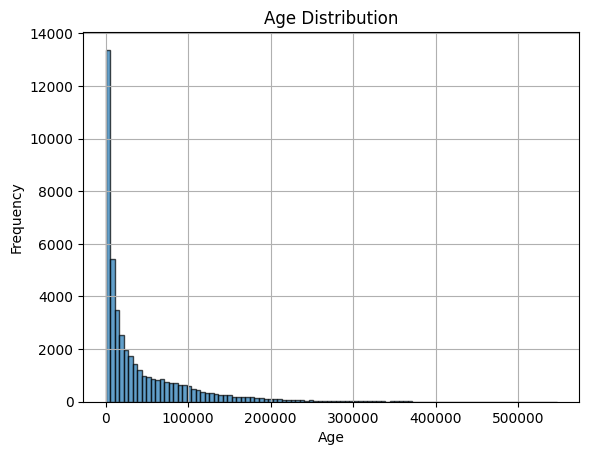

In [ ]:
plt.hist(ds['Planted Acres'], bins=100, edgecolor='k', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.grid(True)
plt.show()

In [ ]:
cond = df_fail['Failed Acres']>0
ds = df_fail[cond]
ds

,FIPS,Crop,Irrigation Practice,Planted Acres,Prevented Acres,Failed Acres,State,County,year
233221,1001,CORN,N,337.14,0.00,12.00,Alabama,Autauga,2017
233223,1001,COTTON,N,8138.78,0.00,41.00,Alabama,Autauga,2017
233226,1001,SOYBEANS,N,657.15,285.95,2.00,Alabama,Autauga,2017
252861,1001,CORN,ALL,590.82,0.00,12.00,Alabama,Autauga,2017
252862,1001,COTTON,ALL,8709.60,0.00,41.00,Alabama,Autauga,2017
...,...,...,...,...,...,...,...,...,...
300991,56043,BARLEY,ALL,12097.91,0.00,39.65,Wyoming,Washakie,2018
252851,56045,HAY,N,1762.60,0.00,42.98,Wyoming,Weston,2017
267300,56045,HAY,ALL,1879.45,0.00,42.98,Wyoming,Weston,2017
388750,56045,WHEAT,N,802.06,0.00,17.53,Wyoming,Weston,2021


In [ ]:
df_fail[(df_fail['FIPS'] == 1083) & (df_fail['Crop'] == 'CORN')]


,FIPS,Crop,Irrigation Practice,Planted Acres,Prevented Acres,Failed Acres,State,County,year
60141,1083,CORN,I,298.80,0.00,0.00,Alabama,Limestone,2012
60142,1083,CORN,N,28540.50,0.00,0.00,Alabama,Limestone,2012
79785,1083,CORN,ALL,28839.30,0.00,0.00,Alabama,Limestone,2012
94635,1083,CORN,I,2193.37,0.00,0.00,Alabama,Limestone,2013
94636,1083,CORN,N,20076.27,765.80,0.00,Alabama,Limestone,2013
114526,1083,CORN,ALL,22269.64,765.80,0.00,Alabama,Limestone,2013
129567,1083,CORN,I,3182.99,0.00,0.00,Alabama,Limestone,2014
129568,1083,CORN,N,18181.72,0.00,27.00,Alabama,Limestone,2014
149271,1083,CORN,ALL,21364.71,0.00,27.00,Alabama,Limestone,2014
164109,1083,CORN,I,3102.18,0.00,0.00,Alabama,Limestone,2015
